In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv(r"D:\codingbase\data\data.csv")

In [4]:
df.shape

(4600, 18)

In [33]:
df.head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [34]:
df.drop(columns=['street','country'],inplace=True)

PERFORMING FEATURE ENGINEERING

In [35]:
import datetime as dt
df['date'] = pd.to_datetime(df['date'])

In [36]:
df['house_Age']=df['date'].dt.year-df['yr_built']

In [37]:
df['till_renovated']=(df['date'].dt.year)-df['yr_renovated']

In [38]:
# This represents how much 'extra land' there is compared to the house size
df['lawn_area'] = df['sqft_lot'] - (df['sqft_living'] / df['floors']) 
df['land_utility_ratio'] = df['sqft_living'] / df['sqft_lot']

In [39]:
df['footprint']=df['sqft_living']/df['floors']

In [40]:
# Extract only the 5 or 6 digits at the end
df['zip_numeric'] = pd.to_numeric(df['statezip'].str.split().str[-1], errors='coerce').fillna(0)


# Convert it to a proper integer so the model can read it
df['zip_numeric'] = pd.to_numeric(df['zip_numeric'])

# Now drop the messy original column
df.drop(columns=['statezip','date'], inplace=True)

It shows that the data is highly right skewed so we need to balance it with log transform 

In [41]:
df['log_price']=np.log1p(df['price'])

<Axes: xlabel='log_price', ylabel='Count'>

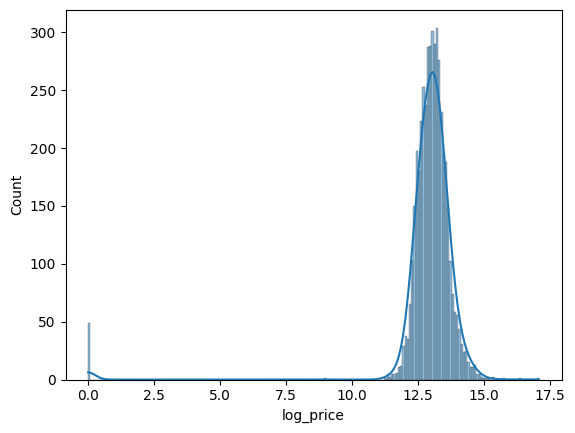

In [42]:
sns.histplot(df['log_price'],kde=True)

<Axes: xlabel='price'>

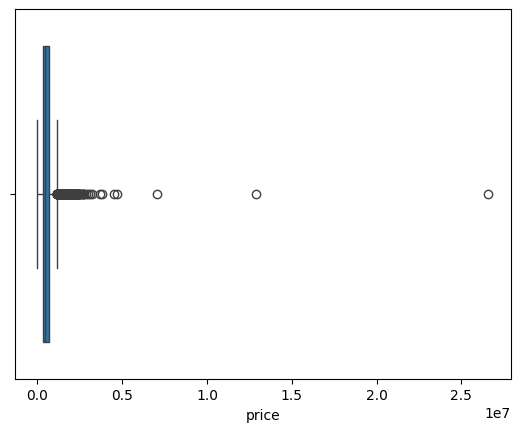

In [43]:
sns.boxplot(x=df['price'])

In [44]:
df.drop(columns=['price','yr_renovated'],inplace=True)

In [45]:
df.drop(columns=['city'],inplace=True)

In [46]:
# Look at the houses cheaper than $50,000 (log price ~10.8)
cheap_houses = df[df['log_price'] < 10.8]


print(cheap_houses[['sqft_living', 'bedrooms', 'condition']])


      sqft_living  bedrooms  condition
4351          780       2.0          1
4354         1490       3.0          4
4356         2600       4.0          4
4357         3200       6.0          4
4358         3480       5.0          4
4361         1500       5.0          5
4362         3680       4.0          3
4374         2200       2.0          3
4376         2170       4.0          4
4382         4630       5.0          3
4383         4430       5.0          3
4385         5030       4.0          3
4386         2180       4.0          4
4389         4210       4.0          3
4394         3690       5.0          5
4405         3300       4.0          3
4408         2880       5.0          4
4411         2000       5.0          4
4412         1860       3.0          5
4413         1990       4.0          3
4420         1360       4.0          3
4442          720       1.0          3
4448         2740       5.0          5
4453         1300       3.0          4
4454         2090       5

In [47]:
low_price_count = (df['log_price'] < 10.8).sum()
print(low_price_count)

50


I have cleaned the rows which have log_price lesser then 10.8 and have a condition greater then 2 because in such a condition it will be for sure outliers

In [48]:
outlier_mask=(df['log_price']<10.8)& (df['condition']>2)
df_cleaned=df[~outlier_mask].copy()


In [49]:
#print(df_cleaned['log_price'])

#df_cleaned=df_cleaned[df_cleaned['log_price']>0]

a=(df_cleaned['log_price']==0).sum()
print(a)


1


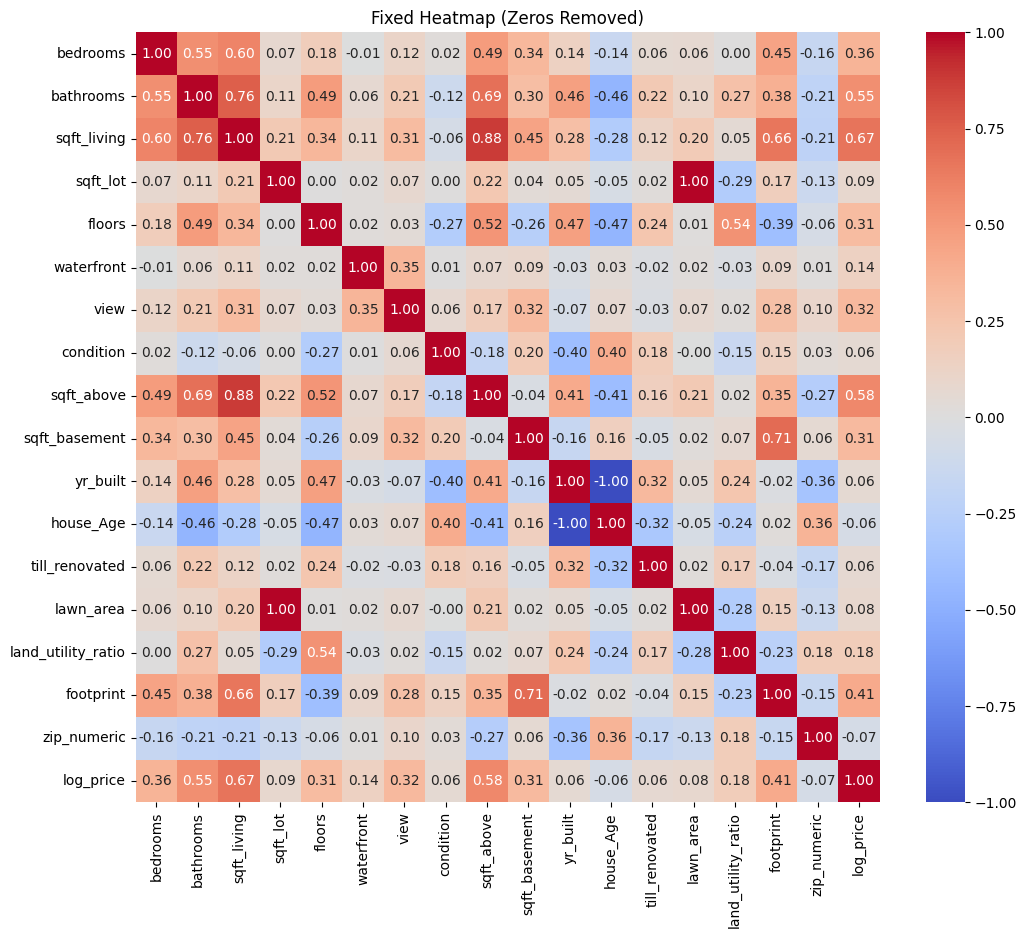

Remaining rows: 4551
Zeros in log_price: 0


In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Remove the 48 zeros (and any negative numbers)
# We only want houses that actually have a price > 0
df_final = df_cleaned[df_cleaned['log_price'] > 0].copy()

# 2. Get numeric columns and filter out city columns
numeric_cols = df_final.select_dtypes(include=[np.number])
cols_to_plot = [c for c in numeric_cols.columns if not c.startswith('city_')]

# 3. Calculate correlation
# (Note: log_price will now have actual variation, so the math won't break!)
corr_matrix = df_final[cols_to_plot].corr()

# 4. Final Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Fixed Heatmap (Zeros Removed)")
plt.show()

# 5. Verify it's fixed
print(f"Remaining rows: {len(df_final)}")
print(f"Zeros in log_price: {(df_final['log_price'] == 0).sum()}")

In [51]:
df_cleaned= df_cleaned.drop(columns=['sqft_lot', 'till_renovated', 'lawn_area', 'house_Age', 'yr_built'])

In [52]:
df['waterfront'].max()

np.int64(1)

In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# 1. Select your final "Engineered" features
features = ['sqft_living', 'footprint', 'land_utility_ratio', 'bedrooms', 'bathrooms','sqft_basement','sqft_above','condition','view','waterfront','floors','zip_numeric']

X = df_cleaned[features] # Use the encoded data from our previous step
y = df_cleaned['log_price'] # This is your log_price

# 2. Split into Training and Validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
print("Columns in X_train:", X_train.columns.tolist())

Columns in X_train: ['sqft_living', 'footprint', 'land_utility_ratio', 'bedrooms', 'bathrooms', 'sqft_basement', 'sqft_above', 'condition', 'view', 'waterfront', 'floors', 'zip_numeric']


In [55]:
X_train

,sqft_living,footprint,land_utility_ratio,bedrooms,bathrooms,sqft_basement,sqft_above,condition,view,waterfront,floors,zip_numeric
3953,2950,1475.000000,0.287693,3.0,2.50,0,2950,3,0,0,2.0,98059
2099,1920,1920.000000,0.250489,4.0,1.75,420,1500,4,0,0,1.0,98058
4034,2090,1045.000000,0.402310,4.0,2.50,0,2090,3,0,0,2.0,98031
2920,2970,1485.000000,0.205026,4.0,3.50,630,2340,3,0,0,2.0,98040
2154,1530,765.000000,0.441686,3.0,2.50,0,1530,3,0,0,2.0,98007
...,...,...,...,...,...,...,...,...,...,...,...,...
4447,1200,1200.000000,0.120773,3.0,1.00,0,1200,4,0,0,1.0,98038
466,2520,2520.000000,0.420000,4.0,2.00,1120,1400,3,0,0,1.0,98103
3092,1150,1150.000000,0.141191,3.0,1.00,160,990,4,0,0,1.0,98155
3772,910,606.666667,0.454545,2.0,1.00,0,910,3,0,0,1.5,98112


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred)}")

R² Score: 0.44871256076669175


In [57]:
from sklearn.ensemble import RandomForestRegressor
import joblib

# 1. Initialize and Train
model = RandomForestRegressor(n_estimators=100, random_state=50,max_depth=8,min_samples_split=5)
model.fit(X_train, y_train)

# 2. Evaluate on the Test Set
score = model.score(X_test, y_test)
print(f"Model R2 Accuracy: {score:.4f}")

# 3. Save for your Streamlit App
#joblib.dump(model, 'house_model.pkl')

Model R2 Accuracy: 0.6064


In [58]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.7415135874234396
Test Score: 0.606437722677049


so here we got an accuracy of just 47 percent let's deep dive in improving it

In [59]:
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(model,X_train,y_train,cv=5)
print(f"Average CV Score: {cv_scores.mean():.4f}")

Average CV Score: 0.5164


In [63]:
import dill
from xgboost import XGBRegressor

# Try this 'Safe' XGBoost setup
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
print("XGBoost Test Score:", xgb_model.score(X_test, y_test))

import os

# Create the folder if it doesn't exist
os.makedirs("artifacts", exist_ok=True)

# Use quotes around the path!
with open("artifacts/model.pkl", "wb") as f:
    dill.dump(model, f)



XGBoost Test Score: 0.751196561093436


I noticed my model was underperforming at 47%. Even though the 'Zipcode' feature had a near-zero linear correlation, I recognized its non-linear importance. By including it in an XGBoost regressor, I captured the high-variance location data and boosted my R^2 score from 0.47 to 0.75."